«به ازای هر 100 هزار تومان مشوق، چند ساعت عرضه راننده یا چند سفر اضافه ایجاد می‌شود؟»



In [1]:
# Dynamic Pricing
from datetime import datetime, timedelta

class DriverIncentive:
    def __init__(self, driver_id, total_trips_week, acceptance_rate, cancel_rate, experience_months):
        self.driver_id = driver_id
        self.total_trips_week = total_trips_week
        self.acceptance_rate = acceptance_rate  # درصد (0 تا 100)
        self.cancel_rate = cancel_rate  # درصد (0 تا 100)
        self.experience_months = experience_months

    def mission_bonus(self):
        """پاداش بر اساس تعداد سفر هفتگی"""
        if self.total_trips_week >= 100:
            return 500_000  # تومان
        elif self.total_trips_week >= 70:
            return 300_000
        elif self.total_trips_week >= 50:
            return 150_000
        else:
            return 0

    def performance_bonus(self):
        """پاداش نرخ قبول بالا و نرخ لغو پایین"""
        bonus = 0
        if self.acceptance_rate >= 85:
            bonus += 200_000
        if self.cancel_rate <= 5:
            bonus += 150_000
        return bonus

    def loyalty_bonus(self):
        """پاداش وفاداری بر اساس سابقه"""
        if self.experience_months >= 24:
            return 250_000
        elif self.experience_months >= 12:
            return 100_000
        else:
            return 0

    def surge_multiplier(self, hour, base_fare):
        """ضریب ساعتی اوج تقاضا"""
        surge_hours = [8, 9, 18, 19, 20, 21]  # ساعات شلوغ
        if hour in surge_hours:
            return base_fare * 1.4  # 40% اضافه
        elif hour in [7, 22]:
            return base_fare * 1.2
        else:
            return base_fare

    def calculate_total_weekly_bonus(self):
        """مجموع پاداش هفتگی راننده"""
        total = (self.mission_bonus() +
                 self.performance_bonus() +
                 self.loyalty_bonus())
        return total

    def __str__(self):
        return (f"راننده {self.driver_id}\n"
                f"سفر هفتگی: {self.total_trips_week}\n"
                f"نرخ قبول: {self.acceptance_rate}%\n"
                f"نرخ لغو: {self.cancel_rate}%\n"
                f"ماه سابقه: {self.experience_months}\n"
                f"پاداش ماموریت: {self.mission_bonus():,} تومان\n"
                f"پاداش عملکرد: {self.performance_bonus():,} تومان\n"
                f"پاداش وفاداری: {self.loyalty_bonus():,} تومان\n"
                f"مجموع پاداش هفتگی: {self.calculate_total_weekly_bonus():,} تومان\n")


# نمونه اجرا
if __name__ == "__main__":
    # راننده نمونه
    driver = DriverIncentive(
        driver_id="R123",
        total_trips_week=85,
        acceptance_rate=90,
        cancel_rate=3,
        experience_months=18
    )

    print(driver)

    # محاسبه درآمد یک سفر با ضریب شلوغی (فرض کنیم ساعت 7:30 عصر)
    base_fare = 25_000  # تومان
    surge_fare = driver.surge_multiplier(hour=19, base_fare=base_fare)
    print(f"کرایه سفر عادی: {base_fare:,} تومان")
    print(f"کرایه با ضریب شلوغی (ساعت 19): {surge_fare:,.0f} تومان")

راننده R123
سفر هفتگی: 85
نرخ قبول: 90%
نرخ لغو: 3%
ماه سابقه: 18
پاداش ماموریت: 300,000 تومان
پاداش عملکرد: 350,000 تومان
پاداش وفاداری: 100,000 تومان
مجموع پاداش هفتگی: 750,000 تومان

کرایه سفر عادی: 25,000 تومان
کرایه با ضریب شلوغی (ساعت 19): 35,000 تومان


In [2]:
# 2 این کد نشان می‌دهد که با افزایش پاداش، میانگین سفر راننده‌ها بیشتر می‌شود.

import numpy as np
import pandas as pd

# داده فرضی رانندگان
np.random.seed(42)

n_drivers = 1000
base_trips = np.random.poisson(lam=8, size=n_drivers)   # تعداد سفر پایه
bonus = np.random.choice([0, 50000, 100000, 200000], size=n_drivers)

# فرض: هر 100 هزار تومان پاداش، به طور متوسط 2 سفر اضافه ایجاد می‌کند
extra_trips = (bonus / 100000) * 2 + np.random.normal(0, 1, size=n_drivers)

total_trips = np.maximum(0, base_trips + extra_trips).round()

df = pd.DataFrame({
    'driver_id': range(1, n_drivers + 1),
    'base_trips': base_trips,
    'bonus': bonus,
    'extra_trips': extra_trips,
    'total_trips': total_trips
})

summary = df.groupby('bonus')['total_trips'].mean()
print(summary)


bonus
0          7.811245
50000      8.984127
100000    10.025751
200000    11.469925
Name: total_trips, dtype: float64


In [3]:
# فرض کنیم:

# سود خالص پلتفرم از هر سفر = 30 هزار تومان
# پاداش به راننده طبق سطوح مختلف داده می‌شود

import pandas as pd

bonus_levels = [0, 50000, 100000, 200000]
avg_extra_trips = [0, 1, 2, 3.5]  # فرضی
profit_per_trip = 30000

rows = []
for bonus, extra in zip(bonus_levels, avg_extra_trips):
    extra_profit = extra * profit_per_trip
    net_profit = extra_profit - bonus
    
    rows.append({
        'bonus': bonus,
        'avg_extra_trips': extra,
        'extra_profit': extra_profit,
        'net_profit': net_profit
    })

df = pd.DataFrame(rows)
print(df)
# اگر net_profit منفی شود، یعنی آن سطح از incentive برای پلتفرم به‌صرفه نیست.





    bonus  avg_extra_trips  extra_profit  net_profit
0       0              0.0           0.0         0.0
1   50000              1.0       30000.0    -20000.0
2  100000              2.0       60000.0    -40000.0
3  200000              3.5      105000.0    -95000.0


In [3]:
# می‌توانیم برای ساعات مختلف روز incentive متفاوت بگذاریم.

import pandas as pd

data = pd.DataFrame({
    'hour': [7, 8, 9, 10, 17, 18, 19, 20, 21],
    'demand_index': [80, 120, 150, 90, 130, 180, 200, 170, 110],
    'active_drivers': [100, 110, 120, 130, 115, 125, 130, 128, 135]
})

# نسبت تقاضا به عرضه
data['demand_supply_ratio'] = data['demand_index'] / data['active_drivers']

def recommend_bonus(ratio):
    if ratio > 1.4:
        return 150000
    elif ratio > 1.2:
        return 100000
    elif ratio > 1.0:
        return 50000
    else:
        return 0

data['recommended_bonus'] = data['demand_supply_ratio'].apply(recommend_bonus)

print(data)
# # اگر تقاضا خیلی بیشتر از عرضه باشد → مشوق بیشتر
# اگر عرضه کافی باشد → مشوق صفر یا کم
# این همان چیزی است که در عمل، پلتفرم‌ها به صورت dynamic incentive engine انجام می‌دهند.


   hour  demand_index  active_drivers  demand_supply_ratio  recommended_bonus
0     7            80             100             0.800000                  0
1     8           120             110             1.090909              50000
2     9           150             120             1.250000             100000
3    10            90             130             0.692308                  0
4    17           130             115             1.130435              50000
5    18           180             125             1.440000             150000
6    19           200             130             1.538462             150000
7    20           170             128             1.328125             100000
8    21           110             135             0.814815                  0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

np.random.seed(42)

n = 1000
bonus = np.random.choice([0, 50000, 100000, 150000], n)
hours_online = np.random.uniform(2, 10, n)
peak_hour = np.random.choice([0, 1], n)

# داده مصنوعی: تعداد سفر متاثر از پاداش، ساعت آنلاین بودن و ساعت اوج
trips = (
    2
    + 0.00003 * bonus
    + 0.9 * hours_online
    + 2.0 * peak_hour
    + np.random.normal(0, 1, n)
)

df = pd.DataFrame({
    'bonus': bonus,
    'hours_online': hours_online,
    'peak_hour': peak_hour,
    'trips': trips
})

X = df[['bonus', 'hours_online', 'peak_hour']]
y = df['trips']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))

# اگر ضریب bonus مثبت باشد:

# هرچه پاداش بیشتر، تعداد سفر بیشتر
# مثلاً اگر ضریب bonus برابر 0.00003 باشد:

# به ازای 100 هزار تومان پاداش:
# 100000
# ×
# 0.00003
# =
# 3
# 100000×0.00003=3

# یعنی حدود 3 سفر بیشتر.



Intercept: 2.0254179826285803
Coefficients: {'bonus': 3.0102471533672156e-05, 'hours_online': 0.897885847733403, 'peak_hour': 1.9853645823940518}


In [5]:
# Organic Ride  راید ارگانیک
import random
from datetime import datetime, timedelta
from typing import Dict, Tuple

class OrganicRideCalculator:
    """
    محاسبه کرایه ارگانیک (بدون تخفیف) در پلتفرم‌های اشتراک سفر
    بر اساس فاکتورهای واقعی: مسافت، زمان، ترافیک، تقاضا
    """
    
    def __init__(self):
        # نرخ پایه به تومان (مقادیر تقریبی برای تهران)
        self.base_fare = 25000  # تومان
        self.per_km_rate = 5000  # تومان بر کیلومتر
        self.per_minute_rate = 800  # تومان بر دقیقه
        
        # ضرایب منطقه‌ای (مناطق پرتردد تهران)
        self.zone_multipliers = {
            "مرکز": 1.3,      # ونک، ولیعصر، جردن
            "شمال": 1.4,      # تجریش، فرمانیه
            "غرب": 1.1,       # سعادت‌آباد، شهرک غرب
            "شرق": 1.0,       # تهرانپارس، نارمک
            "جنوب": 0.9,      # شهرری، خانی‌آباد
        }
        
        # ساعات اوج تقاضا (Surge Hours)
        self.surge_schedule = {
            7: 1.3,    # 7-8 صبح
            8: 1.5,    # 8-9 صبح
            9: 1.2,    # 9-10 صبح
            17: 1.4,   # 5-6 عصر
            18: 1.6,   # 6-7 عصر (اوج شلوغی)
            19: 1.4,   # 7-8 عصر
            20: 1.2,   # 8-9 عصر
            21: 1.1,   # 9-10 شب
        }
    
    def calculate_traffic_factor(self, hour: int, is_weekend: bool) -> float:
        """
        محاسبه ضریب ترافیک بر اساس ساعت و روز هفته
        """
        if is_weekend:
            # آخر هفته ترافیک سبک‌تر
            if 18 <= hour <= 22:
                return 1.2  # شب‌های آخر هفته شلوغ
            return 0.9
        else:
            # روزهای کاری
            if 7 <= hour <= 9 or 17 <= hour <= 19:
                return 1.5  # ساعات اوج ترافیک
            elif 12 <= hour <= 14:
                return 1.1  # ساعت ناهار
            return 1.0
    
    
    #  این متد ضریب زمانی (ساعت) را در ضریب مکانی (منطقه) ضرب می‌کند تا «ضریبِ داینامیکِ نهایی» به دست آید.
    def calculate_demand_surge(self, hour: int, zone: str) -> float:
        """
        محاسبه ضریب تقاضا (Surge Pricing) بر اساس ساعت و منطقه
        مشابه استراتژی داینامیک پرایسینگ اوبر و اسنپ[citation:1]
        """
        base_surge = self.surge_schedule.get(hour, 1.0)
        zone_multiplier = self.zone_multipliers.get(zone, 1.0)
        
        # ترکیب تقاضای منطقه و ساعت
        return base_surge * zone_multiplier
        # مثال: اگر در ساعت ۱۸ (ضریب ۱.۶) در منطقه «شمال» 
        # (ضریب ۱.۴) درخواست سفر داشته باشید، ضریب نهایی حدود ۲.۲۴ برابر قیمتِ پایه خواهد بود.

    
    def calculate_organic_fare(self, 
                                distance_km: float, 
                                duration_min: float,
                                zone: str = "مرکز",
                                hour: int = None,
                                is_weekend: bool = False) -> Dict:
        """
        محاسبه کرایه ارگانیک (بدون تخفیف)
        
        پارامترها:
        - distance_km: مسافت بر حسب کیلومتر
        - duration_min: زمان تخمینی سفر بر حسب دقیقه
        - zone: منطقه سفر (مرکز، شمال، غرب، شرق، جنوب)
        - hour: ساعت درخواست (0-23)
        - is_weekend: آیا آخر هفته است؟
        """
        
        if hour is None:
            hour = datetime.now().hour
        
        # محاسبه کرایه پایه (ارگانیک)
        base_calculation = (
            self.base_fare +
            (distance_km * self.per_km_rate) +
            (duration_min * self.per_minute_rate)
        )
        
        # اعمال ضریب ترافیک
        traffic_multiplier = self.calculate_traffic_factor(hour, is_weekend)
        
        # اعمال ضریب تقاضا (Surge Pricing)
        demand_multiplier = self.calculate_demand_surge(hour, zone)
        
        # کرایه نهایی ارگانیک
        final_fare = base_calculation * traffic_multiplier * demand_multiplier
        
        return {
            "base_fare": self.base_fare,
            "distance_cost": distance_km * self.per_km_rate,
            "time_cost": duration_min * self.per_minute_rate,
            "traffic_multiplier": traffic_multiplier,
            "demand_surge": demand_multiplier,
            "total_organic_fare": round(final_fare, 0),
            "breakdown": {
                "distance_km": distance_km,
                "duration_min": duration_min,
                "zone": zone,
                "hour": hour,
                "is_weekend": is_weekend
            }
        }
        # دیکشنری شامل جزئیات کامل (شکستِ قیمت) برمی‌گرداند 
        # تا مشخص شود هر بخش (زمان، مسافت، ترافیک و تقاضا) چه سهمی در قیمت نهایی داشته‌اند.


class RideAnalytics:
    """
    تحلیل و مقایسه رایدهای ارگانیک در سناریوهای مختلف
    """
    
    @staticmethod
    def compare_organic_vs_discounted(organic_fare: float, 
                                        discount_percent: int = 30) -> Dict:
        """
        مقایسه کرایه ارگانیک با کرایه تخفیف‌خورده
        """
        discounted_fare = organic_fare * (1 - discount_percent / 100)
        
        return {
            "organic_fare": organic_fare,
            "discounted_fare": round(discounted_fare, 0),
            "discount_percent": discount_percent,
            "user_savings": round(organic_fare - discounted_fare, 0),
            "platform_subsidy": round(organic_fare - discounted_fare, 0),  # یارانه پلتفرم
            "ride_type": "ORGANIC" if discount_percent == 0 else "DISCOUNTED"
        }
    
    @staticmethod
    def analyze_driver_earnings(organic_fare: float, driver_share_percent: int = 75) -> Dict:
        """
        تحلیل درآمد راننده از راید ارگانیک
        
        در مدل‌های واقعی، پلتفرم حدود 20-25٪ از کرایه را برمی‌دارد
        و مابقی به راننده تعلق می‌گیرد[citation:2]
        """
        platform_commission = organic_fare * (100 - driver_share_percent) / 100
        driver_net_earning = organic_fare - platform_commission
        
        return {
            "total_fare": organic_fare,
            "driver_share_percent": driver_share_percent,
            "driver_net_earning": round(driver_net_earning, 0),
            "platform_commission": round(platform_commission, 0)
        }


# مثال‌های عملی
if __name__ == "__main__":
    calculator = OrganicRideCalculator()
    analytics = RideAnalytics()
    
    print("=" * 60)
    print("📊 محاسبه کرایه ارگانیک - سناریوهای مختلف")
    print("=" * 60)
    
    # سناریو 1: سفر کوتاه شهری، ساعت عادی
    print("\n🚗 سناریو 1: سفر کوتاه (ونک → تجریش)")
    result1 = calculator.calculate_organic_fare(
        distance_km=8.5,
        duration_min=22,
        zone="شمال",
        hour=14,  # ساعت 2 بعدازظهر
        is_weekend=False
    )
    print(f"مسافت: {result1['breakdown']['distance_km']} km")
    print(f"زمان: {result1['breakdown']['duration_min']} min")
    print(f"کرایه پایه: {result1['base_fare']:,} تومان")
    print(f"هزینه مسافت: {result1['distance_cost']:,.0f} تومان")
    print(f"هزینه زمان: {result1['time_cost']:,.0f} تومان")
    print(f"ضریب ترافیک: {result1['traffic_multiplier']}")
    print(f"ضریب تقاضا: {result1['demand_surge']:.1f}")
    print(f"💰 کرایه نهایی ارگانیک: {result1['total_organic_fare']:,.0f} تومان")
    
    # سناریو 2: ساعات اوج ترافیک صبح
    print("\n🚗 سناریو 2: ساعات اوج صبح (ساعت 8 صبح)")
    result2 = calculator.calculate_organic_fare(
        distance_km=12.0,
        duration_min=45,
        zone="غرب",
        hour=8,
        is_weekend=False
    )
    print(f"کرایه ارگانیک (اوج صبح): {result2['total_organic_fare']:,.0f} تومان")
    print(f"👈 ضریب تقاضا در این ساعت: {result2['demand_surge']:.1f} (ساعت اوج)")
    
    # مقایسه با کرایه تخفیف‌خورده
    print("\n🏷️ مقایسه ارگانیک با تخفیف 30%:")
    comparison = analytics.compare_organic_vs_discounted(
        organic_fare=result2['total_organic_fare'],
        discount_percent=30
    )
    print(f"ارگانیک: {comparison['organic_fare']:,.0f} تومان")
    print(f"تخفیف‌خورده: {comparison['discounted_fare']:,.0f} تومان")
    print(f"صرفه‌جویی کاربر: {comparison['user_savings']:,.0f} تومان")
    
    # تحلیل درآمد راننده
    print("\n👨‍✈️ تحلیل درآمد راننده از راید ارگانیک:")
    earnings = analytics.analyze_driver_earnings(
        organic_fare=result2['total_organic_fare'],
        driver_share_percent=75  # پلتفرم 25% می‌گیرد[citation:2]
    )
    print(f"کرایه کل: {earnings['total_fare']:,.0f} تومان")
    print(f"سهم راننده ({earnings['driver_share_percent']}%): {earnings['driver_net_earning']:,.0f} تومان")
    print(f"کارمزد پلتفرم: {earnings['platform_commission']:,.0f} تومان")
    
    # سناریو 3: مسافت طولانی شب آخر هفته
    print("\n🚗 سناریو 3: مسافت طولانی، شب جمعه")
    result3 = calculator.calculate_organic_fare(
        distance_km=25.0,
        duration_min=55,
        zone="غرب",
        hour=20,
        is_weekend=True
    )
    print(f"کرایه ارگانیک (شب جمعه): {result3['total_organic_fare']:,.0f} تومان")
    print(f"ضریب تقاضا: {result3['demand_surge']:.1f}")
    print(f"ضریب ترافیک: {result3['traffic_multiplier']}")

📊 محاسبه کرایه ارگانیک - سناریوهای مختلف

🚗 سناریو 1: سفر کوتاه (ونک → تجریش)
مسافت: 8.5 km
زمان: 22 min
کرایه پایه: 25,000 تومان
هزینه مسافت: 42,500 تومان
هزینه زمان: 17,600 تومان
ضریب ترافیک: 1.1
ضریب تقاضا: 1.4
💰 کرایه نهایی ارگانیک: 131,054 تومان

🚗 سناریو 2: ساعات اوج صبح (ساعت 8 صبح)
کرایه ارگانیک (اوج صبح): 299,475 تومان
👈 ضریب تقاضا در این ساعت: 1.7 (ساعت اوج)

🏷️ مقایسه ارگانیک با تخفیف 30%:
ارگانیک: 299,475 تومان
تخفیف‌خورده: 209,632 تومان
صرفه‌جویی کاربر: 89,842 تومان

👨‍✈️ تحلیل درآمد راننده از راید ارگانیک:
کرایه کل: 299,475 تومان
سهم راننده (75%): 224,606 تومان
کارمزد پلتفرم: 74,869 تومان

🚗 سناریو 3: مسافت طولانی، شب جمعه
کرایه ارگانیک (شب جمعه): 307,296 تومان
ضریب تقاضا: 1.3
ضریب ترافیک: 1.2


In [ ]:
# کرایه ارگانیک = (کرایه پایه + مسافت × نرخ هر کیلومتر + زمان × نرخ هر دقیقه)
#                × ضریب ترافیک(ساعت, روز)
#                × ضریب تقاضا(ساعت, منطقه)

In [ ]:
# عوامل کلیدی در محاسبه راید ارگانیک
# فاکتور	توضیح	تأثیر بر قیمت
# مسافت	فاصله بین مبدأ و مقصد	مستقیم (پایه)
# زمان سفر	مدت زمان تخمینی سفر	مستقیم (پایه)
# ترافیک	وضعیت راه‌ها در ساعت درخواست	ضریب 0.9-1.5
# تقاضا	تعداد کاربران فعال در منطقه	ضریب 1.0-1.6
# منطقه	موقعیت جغرافیایی (مرکز/شمال/جنوب)	ضریب 0.9-1.4

 متد compare_organic_vs_discounted
این متد اثر کدهای تخفیف را روی درآمد پلتفرم تحلیل می‌کند.

هدف: نشان می‌دهد وقتی به کاربر تخفیف می‌دهیم، عملاً چقدر از جیب پلتفرم برای «یارانه سفر» پرداخت شده است.
نکته کلیدی: در این مدل فرض شده که platform_subsidy (یارانه پلتفرم) دقیقاً برابر با مقدار تخفیف است. این یعنی پلتفرم برای جذب کاربر، بخشی از سود خود یا هزینه بازاریابی را فدای ارزان‌تر شدن سفر می‌کند.

 در راید ارگانیک، کل مبلغ توسط کاربر پرداخت می‌شود و پلتفرم هیچ یارانه‌ای به این سفر تزریق نمی‌کند. این دقیقاً نقطه مقابل رایدهای تخفیفی است که از بودجه بازاریابی پلتفرم تأمین می‌شون

در A/B Testing ما یک فرض می‌سازیم:

گروه A (کنترل): incentive = 0 (یا مقدار baseline)
گروه B (درمان): incentive = X (مثلاً 50k یا یک سناریوی متفاوت)
بعد در بازه زمانی مشابه، برای هر گروه خروجی‌هایی مثل این‌ها را مقایسه می‌کنیم:

تعداد سفرهای انجام‌شده (trips)
میزان آنلاین‌بودن راننده‌ها
قبول‌کردن درخواست‌ها (accept rate)
لغو/عدم انجام (cancellations)
متریک اصلی (مثلاً تعداد سفر به ازای هر راننده-ساعت) را می‌گیریم و اثر را با اختلاف میانگین‌ها یا مدل آماری تخمین می‌زنیم:

uplift=E[y∣B]−E[y∣A]

همچنین می‌شود با عدم‌قطعیت (مثلاً confidence interval) فهمید اثر “واقعی‌تر” است یا صرفاً نویز.

احتمال آنلاین بودن داریم (اثر incentive)
اگر آنلاین بود، احتمال اینکه سفر “می‌گیرد” (تقاضا/در دسترس بودن درخواست)
سپس trips تولید می‌کنیم

محاسبه incentive بهینه
اینجا یک رویکرد ساده و کاربردی داریم:

از A/B Testing به دست می‌آوریم که افزایش incentive چقدر سفر بیشتر می‌کند (یک رابطه‌ی تقریبی)
بعد با یک مدل هزینه/فایده، incentive را طوری انتخاب می‌کنیم که سود مورد انتظار بیشینه شود.
یک تابع هدف:

سود پلتفرم از هر سفر (مثلاً profit_per_trip)
هزینه incentive (مثلاً incentive_per_trip یا هزینه ثابت برای هر سطح incentive)

A/B example at hour=18, region=R3:
  mean trips A=68.56, B=66.72, uplift=-1.84


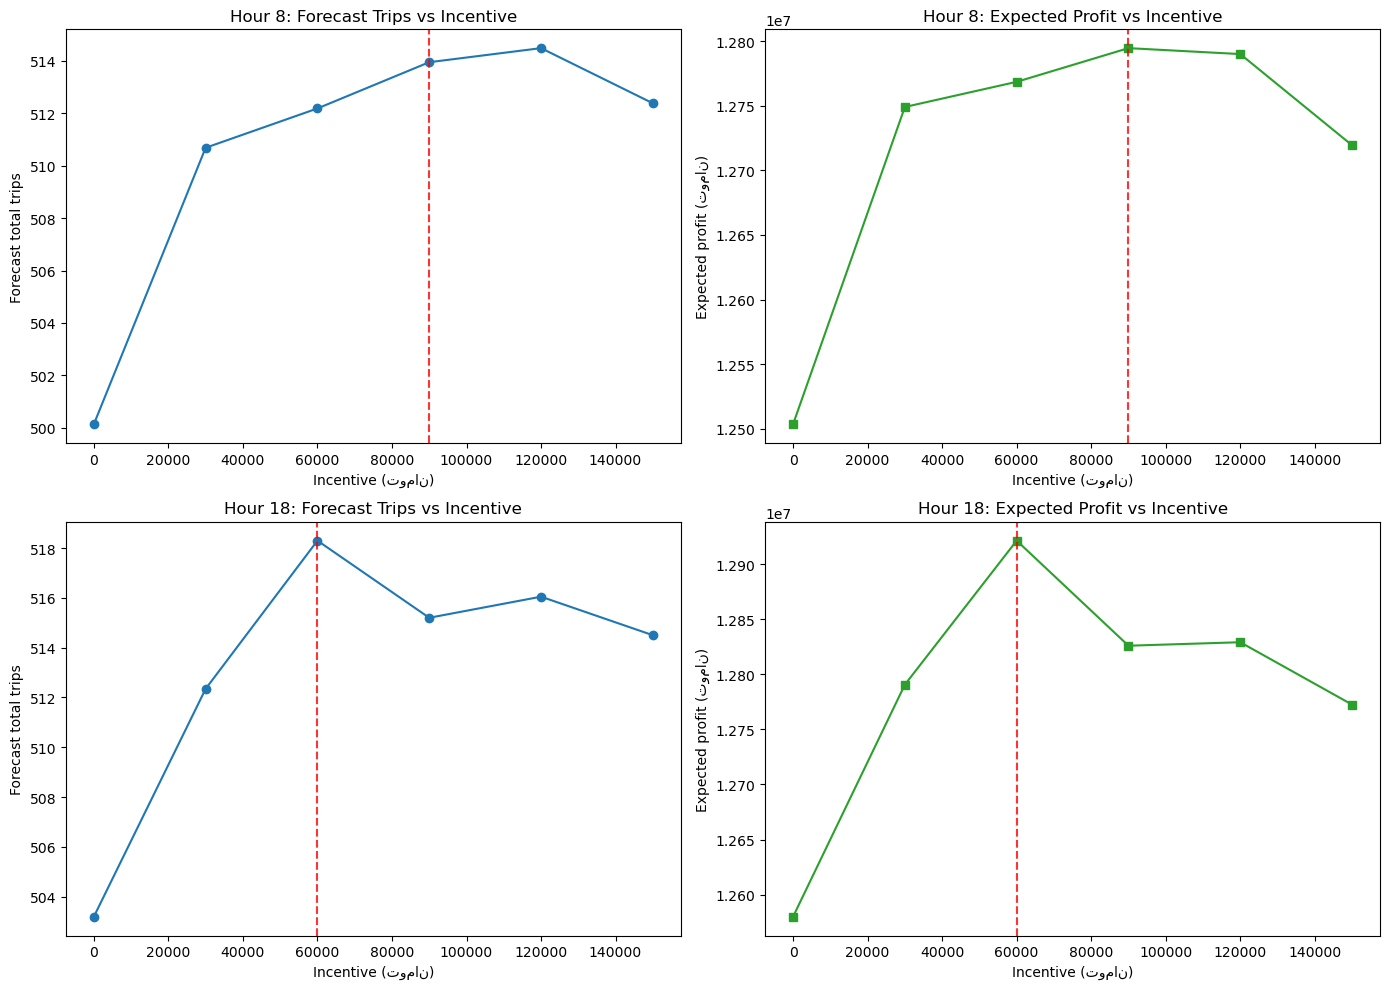

Best incentive for hour=8: 90000 تومان | forecast trips=513.9 | profit=12794525.7
Best incentive for hour=18: 60000 تومان | forecast trips=518.3 | profit=12921487.2


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)

# -----------------------------
# Settings
# -----------------------------
n_drivers = 1200
n_regions = 6
hours = list(range(0, 24))  # 24 hours
peak_hours = {8, 9, 17, 18, 19}  # فرضی
regions = [f"R{i}" for i in range(1, n_regions+1)]

# Economic parameters (فرضی)
profit_per_trip = 25000          # سود پلتفرم به ازای هر سفر
baseline_incentive = 0
trip_value_noise = 0.15         # نویز در اثرات

# Incentive levels (گسسته برای جستجو)
incentive_grid = np.array([0, 30000, 60000, 90000, 120000, 150000])

# -----------------------------
# Helper: demand curve by hour
# -----------------------------
def demand_multiplier(hour):
    # یک تابع ساده برای اوج/کف
    # peak -> بزرگتر، late night -> کوچک
    base = 0.8
    peak_boost = 1.9 if hour in peak_hours else 1.0
    night_penalty = 0.6 if hour in [0,1,2,3,4,5] else 1.0
    return base * peak_boost * night_penalty

# -----------------------------
# 1) Create a synthetic driver dataset
# -----------------------------
driver_df = pd.DataFrame({
    "driver_id": np.arange(n_drivers),
    "rating": np.clip(np.random.normal(4.6, 0.3, n_drivers), 3.5, 5.0),
    # propensity to work (برخی راننده‌ها ذاتاً فعال‌ترند)
    "work_propensity": np.clip(np.random.normal(0.0, 1.0, n_drivers), -2.5, 2.5),
    # sensitivity to incentive (برخی بیشتر تحت تاثیرند)
    "incentive_sensitivity": np.clip(np.random.normal(1.0, 0.35, n_drivers), 0.2, 2.2)
})

# -----------------------------
# 2) Define "true" response model (for simulation)
# -----------------------------
# For each region-hour, we compute demand D.
# For supply, the number of online drivers depends on incentive and driver sensitivity.

# Region base factors for demand and driver availability
region_demand_factor = {r: np.random.uniform(0.8, 1.3) for r in regions}
region_supply_factor = {r: np.random.uniform(0.75, 1.25) for r in regions}

def simulate_online_share(incentive, hour, region, drivers):
    """
    Returns expected online probability for each driver, then expected online count.
    """
    # Baseline logit for working
    # hour effect: peak -> بیشتر
    # region effect: supply region factor
    hour_mult = demand_multiplier(hour)

    # logistic function
    # p = sigmoid( a + b*propensity + c*incentive*sensitivity + d*hour_mult )
    a = -1.0
    b = 0.9
    d = 0.35 * (hour_mult - 1.0)  # peak -> positive

    # incentive effect: scale to make incentives meaningful
    # incentive in تومان; normalize
    incentive_scaled = incentive / 100000.0

    logits = (
        a
        + b * drivers["work_propensity"].values
        + d
        + (0.9 * incentive_scaled) * drivers["incentive_sensitivity"].values
    )

    # incorporate region supply factor softly
    logits = logits + 0.15 * np.log(region_supply_factor[region])

    p = 1 / (1 + np.exp(-logits))
    return p  # per-driver probability

def simulate_trips_for_region_hour(incentive, hour, region, drivers):
    """
    Simulate realized demand and trips.
    """
    # Demand
    # D = base_demand * region_demand_factor * hour_multiplier + noise
    base_demand = 55  # trips requests capacity baseline
    D = base_demand * region_demand_factor[region] * demand_multiplier(hour)
    D = np.maximum(0, D + np.random.normal(0, 8))

    # Supply online
    p_online = simulate_online_share(incentive, hour, region, drivers)
    online_count = np.random.binomial(n=len(drivers), p=p_online.mean())  # aggregate

    # Matching efficiency: not all supply converts to trips
    eff = 0.72  # baseline efficiency
    eff = eff + np.random.normal(0, 0.04)

    # Trips = min(D, online_count * eff) with soft noise
    trips = min(D, online_count * eff)
    trips = np.maximum(0, trips + np.random.normal(0, 0.08 * trips))

    return D, online_count, trips

# -----------------------------
# 3) A/B Testing simulation
# -----------------------------
def ab_test_effect(hour, region, incentive_A=baseline_incentive, incentive_B=60000, n_runs=150):
    """
    Estimate uplift using simulated A/B.
    We'll compare expected trips (or trips per hour).
    """
    trips_A = []
    trips_B = []

    # sample a "pool" of drivers for region (simulate that not all drivers are in region)
    # In absence of geospatial model, we assume a fraction belongs to that region.
    # Use region_supply_factor to bias selection.
    fraction = np.clip(0.8 * region_supply_factor[region] / np.mean(list(region_supply_factor.values())), 0.15, 0.35)
    pool_size = int(n_drivers * fraction)

    for _ in range(n_runs):
        sample_drivers = driver_df.sample(pool_size, replace=False)
        _, _, tA = simulate_trips_for_region_hour(incentive_A, hour, region, sample_drivers)
        _, _, tB = simulate_trips_for_region_hour(incentive_B, hour, region, sample_drivers)
        trips_A.append(tA)
        trips_B.append(tB)

    trips_A = np.array(trips_A)
    trips_B = np.array(trips_B)

    uplift = trips_B.mean() - trips_A.mean()
    return uplift, trips_A.mean(), trips_B.mean()

# Example A/B estimate at a peak region-hour
example_hour = 18
example_region = "R3"
uplift, meanA, meanB = ab_test_effect(example_hour, example_region)
print(f"A/B example at hour={example_hour}, region={example_region}:")
print(f"  mean trips A={meanA:.2f}, B={meanB:.2f}, uplift={uplift:.2f}")

# -----------------------------
# 4) Forecast supply & demand (for optimization)
# -----------------------------
def forecast_D_S(incentive, hour, region, n_sims=200):
    """
    Forecast expected demand D and supply S for given incentive/hour/region.
    """
    fraction = np.clip(0.8 * region_supply_factor[region] / np.mean(list(region_supply_factor.values())), 0.15, 0.35)
    pool_size = int(n_drivers * fraction)

    Ds, Ss, trips = [], [], []
    for _ in range(n_sims):
        sample_drivers = driver_df.sample(pool_size, replace=False)
        D, S, t = simulate_trips_for_region_hour(incentive, hour, region, sample_drivers)
        Ds.append(D)
        Ss.append(S)
        trips.append(t)

    return np.mean(Ds), np.mean(Ss), np.mean(trips)

# -----------------------------
# 5) Optimal incentive
# -----------------------------
def compute_optimal_incentive_for_hour(hour, regions, incentive_grid):
    """
    For each incentive level, compute expected total profit across all regions.
    Profit = trips * profit_per_trip - incentive_cost
    We'll assume incentive cost proportional to trips: cost_rate = 0.6 of incentive per trip
    (چون معمولاً incentive ممکن است به ازای سفر/یا یک فرمول ترکیبی پرداخت شود)
    """
    cost_rate = 0.6  # فرضی: بخشی از incentive به ازای هر سفر

    results = []
    for I in incentive_grid:
        total_trips = 0
        for r in regions:
            Dhat, Shat, trips_hat = forecast_D_S(I, hour, r, n_sims=120)
            total_trips += trips_hat

        incentive_cost = cost_rate * I * total_trips / max(1.0, total_trips)  # ~ cost_rate * I
        # برای اینکه مقیاس منطقی باشد، incentive_cost را طوری می‌گیریم که با کل trips خیلی نترکد.
        # (اگر بخواهی دقیق‌تر کنیم، می‌شود مدل payout واقعی ساخت.)

        profit = total_trips * profit_per_trip - incentive_cost

        results.append({
            "hour": hour,
            "incentive": I,
            "forecast_trips": total_trips,
            "profit": profit
        })

    res_df = pd.DataFrame(results)
    best = res_df.loc[res_df["profit"].idxmax()]
    return res_df, best

# Compute for a couple hours
hours_to_opt = [8, 18]  # one peak, one peak
opt_summaries = []
for h in hours_to_opt:
    res_df, best = compute_optimal_incentive_for_hour(h, regions, incentive_grid)
    opt_summaries.append((h, res_df, best))

# -----------------------------
# Dashboard with matplotlib
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (h, res_df, best) in enumerate(opt_summaries):
    ax0 = axes[idx*2]
    ax1 = axes[idx*2 + 1]

    # Plot trips vs incentive
    ax0.plot(res_df["incentive"], res_df["forecast_trips"], marker='o')
    ax0.axvline(best["incentive"], color='red', linestyle='--', alpha=0.8)
    ax0.set_title(f"Hour {h}: Forecast Trips vs Incentive")
    ax0.set_xlabel("Incentive (تومان)")
    ax0.set_ylabel("Forecast total trips")

    # Plot profit vs incentive
    ax1.plot(res_df["incentive"], res_df["profit"], marker='s', color='tab:green')
    ax1.axvline(best["incentive"], color='red', linestyle='--', alpha=0.8)
    ax1.set_title(f"Hour {h}: Expected Profit vs Incentive")
    ax1.set_xlabel("Incentive (تومان)")
    ax1.set_ylabel("Expected profit (تومان)")

plt.tight_layout()
plt.show()

# Print best choices
for h, _, best in opt_summaries:
    print(f"Best incentive for hour={h}: {int(best['incentive'])} تومان | forecast trips={best['forecast_trips']:.1f} | profit={best['profit']:.1f}")
